# COVID-19 human lungs IMC data set - Topological data analysis

Contents:
1. Data preparation and preliminary analysis
2. Persistent homology (PH) computations
3. Visualisation of PH (PWDS)
4. Vectorisations
5. Clustering

In [1]:
# Basic libraries
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import time

plt.rcParams['font.family'] = 'Arial'
from matplotlib import ticker

# Statistics
import scipy.stats as stats

# Nearest neighbour analysis
from sklearn.neighbors import NearestNeighbors

# Persistence homology
import gudhi
import gudhi.representations.vector_methods # Betti curves computation 
from persim import PersistenceImager # Persistence images computation 
import collections
collections.Iterable = collections.abc.Iterable # Needed for persim

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sil_score

# Ignore FutureWarnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1. Data preparation and preliminary analysis

In [2]:
# Global variables (can be changed depending on data set)

stages = ['HC','Alveolitis','DAD','OP']
stages_colors = ['blue','orange','red','firebrick']
line_styles = ['solid', 'dashed', 'dashdot', 'dotted']
stages_len = [4,10,10,8]

### Load data

- 2 __healthy__ patients (HC) [Oxford Radcliffe Biobank]: 4 ROIs
- 12 __COVID__ patients, 4 at each histopathology state [University of Navarra]:
    - Alveolitis (ALV): 10 ROIs
    - Diffuse alveolar damage (DAD): 8 ROIs
    - Organising Pneumonia: 8 ROIs

The three disease states are histopathology-based temporally progressive states. Hispathology is the diagnosis and study of diseases of the tissues.

In [3]:
# Create data frame
df_cells = pd.read_csv('data/HyperionCOVID19CellIMarkers.csv', index_col = None, keep_default_na=False) # Pandas reads 'NA' as NaN by default

# Find cell types and broad cell types
cell_types = df_cells.annotations.value_counts().index.tolist() # 50 cell types

# Broad cell types
broad_cell_types = ['all','str','imm']

# Sort the cell types by relevance (total number of cells present in the samples)
ct_num = []
for ct in cell_types:
    ct_num.append(len(df_cells[df_cells.annotations == ct]))
cell_types = [x for _, x in sorted(zip(ct_num, cell_types), key=lambda pair: pair[0],reverse=True)]

# Find sample names by disease state

sample_ids = {}
for s in stages:
    sample_ids[s] = df_cells[df_cells.disease_state == s].sample_id.value_counts().index.tolist()

# All rois in a list

rois = []
for s in stages:
        rois = rois + sample_ids[s]

# Simplified ROIs names
rois_titles = []
for s in stages:
    for roi in sample_ids[s]:
        sample_num = roi.split('_')[2]
        roi_num = roi.split('_')[4]
        rois_titles.append(s.replace('Alveolitis','ALV') + sample_num + 'R' + roi_num)

In [4]:
# Create data dictionary

point_clouds = {}

for roi in rois:
    for ct in cell_types:
        cells = df_cells[(df_cells.sample_id == roi)&(df_cells.annotations == ct)]
        x = cells.x.astype(float).values
        y = cells.y.astype(float).values
        
        point_clouds[roi,ct]=[x,y]

    # All cells
    x = df_cells[(df_cells.sample_id == roi)].x.astype(float).values
    y = df_cells[(df_cells.sample_id == roi)].y.astype(float).values
    point_clouds[roi,'all']=[x,y]

    # Structural cells
    x = df_cells[(df_cells.sample_id == roi) & (df_cells.broad_celltypes == 'structural')].x.astype(float).values
    y = df_cells[(df_cells.sample_id == roi) & (df_cells.broad_celltypes == 'structural')].y.astype(float).values
    point_clouds[roi,'str']=[x,y]

    # Immune cells
    x = df_cells[(df_cells.sample_id == roi) & (df_cells.broad_celltypes.isin(['myeloid', 'lymphocyte']))].x.astype(float).values
    y = df_cells[(df_cells.sample_id == roi) & (df_cells.broad_celltypes.isin(['myeloid', 'lymphocyte']))].y.astype(float).values
    point_clouds[roi,'imm']=[x,y]

### Plot data

In [5]:
sizes = {}

for roi in rois:
    sizes[roi] = (1.5*max(point_clouds[roi,'all'][0])/2000,1.5*max(point_clouds[roi,'all'][1])/2000)

In [6]:
# OPTION: Only plot 25 most common cell_types and group the rest in 'Other cell types' category

# Choose colors
colors_ct = ['#3cb44b', '#4363d8', '#e6194B', '#911eb4', '#ffe119', '#f58231', '#42d4f4', '#f032e6', '#bfef45', \
          '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', \
          '#000075', '#a9a9a9', '#000000', '#4c005c', '#94ffb5', '#005c31', '#990000']

# Colors are globally attributed by cell counts, regardless of the pulp
ct2color = {cell_types[i]:colors_ct[i] for i in range(len(colors_ct)-1)}
ct2color['Other cell types'] = colors_ct[-1]

In [7]:
# Plots with correct aspect ratio. Coloured by cell types

j = 0
k = 0
for s in stages:
    for roi in sample_ids[s]:

        fig = plt.figure(figsize=sizes[roi])
        plt.title(rois_titles[j],fontsize=8, color = stages_colors[k])
        j+=1

        plt.axis('equal')
        
        plt.xticks(fontsize=3)
        plt.yticks(fontsize=3)

        # Plot the 25 most common cell types individually
        for i in range(len(colors_ct) - 1):  # 25 colors for top 25 cell types
            ct = cell_types[i]
            x = point_clouds[roi, ct][0]
            y = point_clouds[roi, ct][1]
            if len(x) > 0:
                plt.scatter(x, y, s=0.5, marker='.', edgecolors='none', color=ct2color[ct])

        # Plot all remaining cell types as 'Other'
        other_color = colors_ct[-1]
        for ct in cell_types[len(colors_ct) - 1:]:  # Remaining cell types
            x = point_clouds[roi, ct][0]
            y = point_clouds[roi, ct][1]
            if len(x) > 0:
                plt.scatter(x, y, s=0.5, marker='.', edgecolors='none', color=other_color)
        
        plt.savefig('data_plots/'+s+'-'+roi+'.png',dpi=600, bbox_inches='tight')
        plt.close(fig)
        
    k+= 1

In [8]:
# Create the legend

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', linewidth = 0, label=ct, markerfacecolor=ct2color[ct], markersize=15)\
                   for ct in ct2color]

fig, ax = plt.subplots(1,1, figsize=(8, 4))
ax.legend(handles=legend_elements, loc='center',prop={'size':20},frameon=False)
ax.axis('off')
plt.savefig('data_plots/legend.png',dpi=300, transparent = True, bbox_inches='tight');
plt.close()

### Density analysis

In [9]:
densities_pvalue = {}
densities = {}

for ct in broad_cell_types + cell_types:
    feature = [len(point_clouds[roi, ct][0])/(max(point_clouds[roi,'all'][0])*max(point_clouds[roi,'all'][1])) for roi in rois]
    densities[ct] = feature
    densities_pvalue[ct] = stats.ttest_ind(feature[0:stages_len[0]], feature[stages_len[0]:stages_len[0]+sum(stages_len[1:])], axis=0, equal_var=False, alternative='two-sided').pvalue

Text(0.5, 1.0, '')

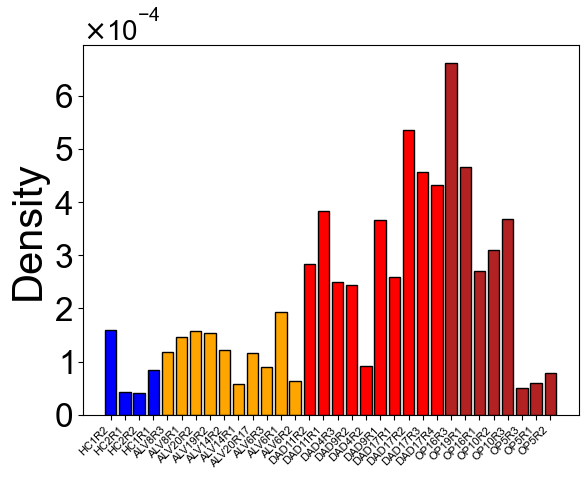

In [10]:
ct = 'Endothelial cells'

heights = densities[ct]

# Define the number of bins (you can adjust this based on your data)
bins = len(rois)

# Define colours
colors_hist = ['blue'] * stages_len[0] + ['orange'] * stages_len[1] + ['red'] * stages_len[2] + ['firebrick'] * stages_len[3]

# Create the bar plot
bars = plt.bar(range(len(rois)), heights, color=colors_hist, edgecolor='black')

# Set the custom x-ticks (labels) and remove numeric labels
plt.xticks(range(len(rois)), labels=rois_titles, rotation=45, ha='right', size=8)
plt.yticks(size = 24)

plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) #, scilimits=None, useOffset=None, useLocale=None, useMathText=None)

# Increase the font size of the scientific offset in the top-left corner
offset_text = plt.gca().yaxis.get_offset_text()
offset_text.set_visible(True)
offset_text.set_fontsize(20) 

# Set labels and title
plt.ylabel("Density", size = 30)
plt.title("")

### Nearest neighbout distance

In [11]:
nn = NearestNeighbors(n_neighbors=1, radius=100.0, metric='minkowski', p=2) # Euclidian metric
nn_distances = []

for roi in rois:
    x = point_clouds[roi,'all'][0]
    y = point_clouds[roi,'all'][1]
    data = np.vstack((x,y)).T
    nn.fit(data)
    nn_distances = nn_distances + list(nn.kneighbors()[0])

print('Nearest Neighbour distance (global):')
print('mean: ', np.mean(nn_distances))
print('std: ', np.std(nn_distances))

nnd_mean = np.mean(nn_distances)

Nearest Neighbour distance (global):
mean:  8.620905552308718
std:  2.5288122239653132


### Functions for analysis

#### Create class of topological descriptors

In [12]:
class topological_descriptor:
    def __init__(self, vectors, point_cloud, filtration, degree, type):
        self.vectors = vectors
        self.point_cloud = point_cloud
        self.filtration = filtration
        self.degree = degree
        self.type = type
        self.label = ' '.join([self.point_cloud, self.filtration, 'H'+str(self.degree), self.type])
        self.pi_shape = None
        self.twoclust = None
        self.fourclust = None
        self.threeclust = None

#### Computation of Betti curves

In [13]:
# Computation of Betti curve

def betti_curves(dgms_list, step, normalise = True):
    min_param = 0
    max_param = math.ceil(np.vstack(dgms_list).max(axis=0)[1])
    bc = gudhi.representations.vector_methods.BettiCurve(resolution=None, predefined_grid=np.array(range(min_param,max_param,step)))

    betti_curves = []

    for i in range(len(rois)):
        if normalise == True:
            norm = len(dgms_list[i])
        else:
            norm = 1
        betti_curves.append(np.array(bc(dgms_list[i])/norm))
    
    return betti_curves


#### Plotting of Betti curves

In [14]:
def plot_betti_curves(curves, step, figsize = (10,3), legend = False, pos_legend = (1.1,0.6), title = '', save = False, filename = '', max_param = np.inf, min_param = 0, max_y = np.inf):

    global stages_colors, line_styles, stages, stages_len

    plt.style.use('default')
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    if max_param == np.inf:
        max_param = len(curves[0]) # All betti curves need to have the same length, they will if computed with my function 
    
    if max_y < np.inf:
        plt.ylim(-0.01,max_y)
    
    plt.xlabel('Scale parameter value',size = 20,labelpad=10)
    plt.ylabel('Proportion of\nlive features',size = 20, labelpad=10) # 'Proportion of \n live features', rotation='horizontal')
    plt.xticks(size = 16)
    plt.yticks(size = 16)

    count = 0
    for i in range(len(stages)):
        s = stages[i]

        for j in range(stages_len[i]):
            plt.plot(np.array(range(min_param,max_param,step)),curves[count + j][min_param:max_param], \
                     color=stages_colors[i], linestyle = line_styles[i], linewidth=1, label = s) # s = 0.2)

        count = count + stages_len[i]

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))       
        lgnd = fig.legend(by_label.values(), by_label.keys(),bbox_to_anchor=pos_legend)

        for i in range(0,len(stages)):
            lgnd.legend_handles[i]._sizes = [15]

    if save == True:
        fig.savefig(filename,facecolor='white', transparent=False,dpi=200, bbox_inches = 'tight')
    
    return fig

In [15]:
def plot_betti_curves_diseased(curves, step, figsize = (10,3), legend = False, pos_legend = (1.1,0.6), title = '', save = False, filename = '', max_param = np.inf, min_param = 0, max_y = np.inf):

    global stages_colors, line_styles, stages, stages_len

    plt.style.use('default')
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    if max_param == np.inf:
        max_param = len(curves[0]) # All betti curves need to have the same length, they will if computed with my function 
    
    if max_y < np.inf:
        plt.ylim(-0.01,max_y)
    
    plt.xlabel('Scale parameter value')
    plt.ylabel('Proportion of live features') # 'Proportion of \n live features', rotation='horizontal')
    
    
    count = 0
    for i in range(1,len(stages)):
        s = stages[i]

        for j in range(stages_len[i]):
            plt.plot(np.array(range(0,max_param*step,step)),curves[count + j], \
                     color=stages_colors[i], linestyle = line_styles[i-1], linewidth=1, label = s) # s = 0.2)

        count = count + stages_len[i]

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))       
        lgnd = fig.legend(by_label.values(), by_label.keys(),bbox_to_anchor=pos_legend)

        for i in range(0,len(stages)-1):
            lgnd.legend_handles[i]._sizes = [15]

    if save == True:
        fig.savefig(filename,facecolor='white', transparent=False,dpi=200, bbox_inches = 'tight')
    
    return fig

#### Computation of elementary statistics

In [16]:
# Copied definition from topological_descriptor library

def GetPersStats(barcode,app=False,*p):
    if (np.size(barcode) > 0):
        # Average of Birth and Death of the barcode
        bc_av0, bc_av1 = np.mean(barcode, axis=0)
        # STDev of Birth and Death of the barcode
        bc_std0, bc_std1 = np.std(barcode, axis=0)
        # Median of Birth and Death of the barcode
        bc_med0, bc_med1 = np.median(barcode, axis=0)
        # Intercuartil range of births and death
        bc_iqr0, bc_iqr1 = np.subtract(*np.percentile(barcode, [75, 25], axis=0)) 
        # Range of births and deaths
        bc_r0, bc_r1=np.max(barcode, axis=0) - np.min(barcode, axis=0)
        # Percentiles of births and deaths
        bc_p10_0,bc_p10_1=np.percentile(barcode, 10, axis=0)
        bc_p25_0,bc_p25_1=np.percentile(barcode,25, axis=0)
        bc_p75_0,bc_p75_1=np.percentile(barcode, 75, axis=0)
        bc_p90_0,bc_p90_1=np.percentile(barcode, 90, axis=0)
        
        
        avg_barcodes = (barcode[:,1] + barcode[:,0])/2
        # Average of midpoints of the barcode
        bc_av_av = np.mean(avg_barcodes)
        # STDev of midpoints of the barcode
        bc_std_av = np.std(avg_barcodes)
        # Median of midpoints of the barcode
        bc_med_av = np.median(avg_barcodes)
        # Intercuartil range of midpoints
        bc_iqr_av = np.subtract(*np.percentile(avg_barcodes, [75, 25])) 
        # Range of midpoints
        bc_r_av = np.max(avg_barcodes) - np.min(avg_barcodes)
        # Percentiles of midpoints
        bc_p10_av = np.percentile(barcode, 10)
        bc_p25_av=np.percentile(barcode,25)
        bc_p75_av=np.percentile(barcode, 75)
        bc_p90_av=np.percentile(barcode, 90)
        
        diff_barcode = np.subtract([i[1] for i in barcode], [
                                   i[0] for i in barcode])
        diff_barcode = np.absolute(diff_barcode)
        # Average of the length of Bars
        bc_lengthAverage = np.mean(diff_barcode)
        # STD of length of Bars
        bc_lengthSTD = np.std(diff_barcode)
        # Median of length of Bars
        bc_lengthMedian = np.median(diff_barcode)
        # Intercuartil range of length of the bars
        bc_lengthIQR= np.subtract(*np.percentile(diff_barcode, [75, 25]))
        # Range of length of the bars
        bc_lengthR=np.max(diff_barcode) - np.min(diff_barcode)
        # Percentiles of lengths of the bars
        bc_lengthp10=np.percentile(diff_barcode, 10)
        bc_lengthp25=np.percentile(diff_barcode, 25)
        bc_lengthp75=np.percentile(diff_barcode, 75)
        bc_lengthp90=np.percentile(diff_barcode, 90)
        
        # Number of Bars
        bc_count = len(diff_barcode)
        # Persitent Entropy
        # ent = GetNewMethods.Entropy()
        # bc_ent = ent.fit_transform([barcode])
        
        bar_stats = np.array([bc_av0, bc_av1, bc_std0, bc_std1, bc_med0, bc_med1,
                              bc_iqr0, bc_iqr1, bc_r0, bc_r1, bc_p10_0, bc_p10_1, 
                              bc_p25_0, bc_p25_1, bc_p75_0, bc_p75_1, bc_p90_0, 
                              bc_p90_1, 
                              bc_av_av, bc_std_av, bc_med_av, bc_iqr_av, bc_r_av, bc_p10_av, 
                              bc_p25_av, bc_p75_av, bc_p90_av, bc_lengthAverage, bc_lengthSTD, 
                              bc_lengthMedian, bc_lengthIQR, bc_lengthR, bc_lengthp10,  
                              bc_lengthp25,  bc_lengthp75,  bc_lengthp90, bc_count])
        if app == True:
            bar_stats = np.array([bc_av0, bc_std0, bc_med0, bc_iqr0, bc_r0, bc_p10_0, bc_p25_0, bc_p75_0, bc_p90_0,
                              bc_av1, bc_std1, bc_med1, bc_iqr1, bc_r1, bc_p10_1, bc_p25_1, bc_p75_1, bc_p90_1,
                              bc_av_av, bc_std_av, bc_med_av, bc_iqr_av, bc_r_av, bc_p10_av, bc_p25_av, bc_p75_av, bc_p90_av,
                              bc_lengthAverage, bc_lengthSTD, bc_lengthMedian, bc_lengthIQR, bc_lengthR, bc_lengthp10, bc_lengthp25, bc_lengthp75, bc_lengthp90,
                              bc_count])
    else:
        bar_stats = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
                              0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                              0, 0,0, 0])

    bar_stats[~np.isfinite(bar_stats)] = 0

    return bar_stats

#### Analysis of clustering results

In [17]:
# Compare clusterings.

# Relabel to make comparisson easier

def relabel(clustering, new_labels = None):
    labels = list(dict.fromkeys(clustering)) # Eliminate duplicates while preserving the original order of appearance
    if new_labels == None:
        new_labels = range(len(labels)) # Relabel by integers
    translation = dict(zip(labels,new_labels))
    new_clustering = [translation[l] for l in clustering]
    return new_clustering

def good_clustering(clustering, true_labels):  
    if relabel(clustering) == relabel(true_labels):
        return True
    else:
        return False

def partial_clustering(clustering, true_labels, some_labels):

    clust = relabel(clustering)
    truth = relabel(true_labels)

    # Need to translate some_labels, which are a subset of true_labels
    labels = list(dict.fromkeys(true_labels))
    new_labels = range(len(labels))
    translation = dict(zip(labels,new_labels))
    some = [translation[l] for l in some_labels]

    clust_ = []
    for a in clust:
        if a in some:
            clust_.append(a)
        else:
            clust_.append(np.inf)

    truth_ = []
    for a in truth:
        if a in some:
            truth_.append(a)
        else:
            truth_.append(np.inf)

    if clust_ == truth_:
        return True
    else:
        return False

In [18]:
def label2cluster(labels, objects):
    clusters = {}
    label_set = set(labels)
    for l in label_set:
        clusters[l] = []
    
    for i in range(len(labels)):
        clusters[labels[i]].append(objects[i])
    
    return clusters

In [19]:
# Personalised Rand score.
# We use classical rand score, and a modification that looks for clusterings that classify one stage particularly well.

def rand_score_pers(true_labels, pred_labels, subset = None):
    if subset == None:
        subset = range(len(true_labels))
    
    TP = 0.
    TN = 0.
    FP = 0.
    FN = 0.

    pairs = []

    for i in subset:
        for j in range(len(true_labels)):
            if i!=j and {i,j} not in pairs:
                pairs.append({i,j})
                
                if (true_labels[i] == true_labels[j] and pred_labels[i] == pred_labels[j]):
                    TP += 1
                
                if (true_labels[i] != true_labels[j] and pred_labels[i] != pred_labels[j]):
                    TN += 1

                if (true_labels[i] != true_labels[j] and pred_labels[i] == pred_labels[j]):
                    FP += 1
                
                if (true_labels[i] == true_labels[j] and pred_labels[i] != pred_labels[j]):
                    FN += 1

    return (TP + TN)/(TP+TN+FP+FN)

#### Plotting of PCAs

In [20]:
# Define a PCA function tailored for our dataset.

def plot_pca(feature, n_comp = 2, title = '', legend = True, save = False, ticks = True, filename = ''): 
    
    global stages_colors, stages, stages_len
    
    pca = PCA(n_components=n_comp)
    
    feature_pca = (pca.fit_transform(feature)).T

    fig, ax = plt.subplots() 

    fig.suptitle(title)
    plt.axis('equal')
    plt.xlabel('PC1',size = 26)
    plt.ylabel('PC2', size = 26)

    count = 0

    for i in range(len(stages)):
        s = stages[i]

        ax.scatter(feature_pca[0][count:count+stages_len[i]], feature_pca[1][count:count+stages_len[i]], s = 100, 
                   color=stages_colors[i],label=s)

        count = count + stages_len[i]

    if not ticks:
        ax.set_xticks([],[])
        ax.set_yticks([],[])
    
    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))       
        lgnd = fig.legend(by_label.values(), by_label.keys(),bbox_to_anchor=(1.15, 0.6))

        for i in range(0,len(stages)):
            lgnd.legend_handles[i]._sizes = [15]
    
    
    if save:
        fig.savefig(filename,dpi=200, bbox_inches = 'tight')

    return fig

In [21]:
# Define a PCA function tailored for our dataset only for diseased samples.

def plot_pca_diseased(feature, n_comp = 2, title = '', save = False, filename = '', clustering = None):
    
    global stages_colors, stages, stages_len
    
    pca = PCA(n_components=n_comp)
    
    feature_pca = (pca.fit_transform(feature[stages_len[0]:])).T

    fig, ax = plt.subplots() 

    fig.suptitle(title)
    plt.axis('equal')
    plt.xlabel('PC1', size = 26)
    plt.ylabel('PC2', size = 26)

    count = 0

    # Markers to indicate clustering work, but need to sort out legend
    
    if clustering != None:
        markers = relabel(clustering,new_labels=["o","x","s"])

    if clustering == None:
        markers = len(feature)*["o"]

    for i in range(1,len(stages)):
        s = stages[i]

        for j in range(count,count+stages_len[i]):
            ax.scatter(feature_pca[0][j], feature_pca[1][j], s = 100, 
                       color=stages_colors[i],label=s, marker=markers[j])
        
        count = count + stages_len[i]

    if save:
        fig.savefig(filename,dpi=200, bbox_inches = 'tight')

    return fig

## 2. Persistent homology computations

In [22]:
dgms = {}

In [23]:
deg_max = 1 # We compute up to degree 1 homology (clusters and loops) 
filtrations = ['alpha', 'witness'] 

### Alpha filtration

In [24]:
alpha_dgms = {}

# Create empty lists to save persistence diagrams
for ct in cell_types + broad_cell_types:
    alpha_dgms[ct] = [[] for _ in range(deg_max+1)]

In [25]:
min_pers = 0    # We don't rule out features of very low persistence

for ct in broad_cell_types + cell_types:
    for roi in rois:
        data = np.vstack((point_clouds[roi,ct][0], point_clouds[roi,ct][1])).T
        
        # Computation of persistent homology 
        stree = gudhi.AlphaComplex(points = data).create_simplex_tree()
        dgm_raw = stree.persistence(min_persistence=min_pers)

        dgm_rearranged = [[] for _ in range(deg_max+1)] # We rearrange the format of the persistence diagrams
        for point in dgm_raw:
            dgm_rearranged[point[0]].append([np.sqrt(point[1][0]),np.sqrt(point[1][1])]) # gudhi works with the square of the scale parameter for computational reasons, we take sqrt
        
        alpha_dgms[ct][0].append(np.array(dgm_rearranged[0][1:])) # Take out infinity point
        alpha_dgms[ct][1].append(np.array(dgm_rearranged[1]))

In [26]:
dgms['alpha'] = alpha_dgms

### Witness filtration

#### Upload pre-computed results

In [27]:
witness_dgms = {}

for ct in broad_cell_types:
    # Initialize: one list per degree, and inside each, one list per sample
    witness_dgms[ct] = [[[] for _ in rois] for _ in range(deg_max + 1)]

    with open('witness_' + ct.replace(' ', '_') + ".txt", "r") as f:
        for line in f:
            if line.startswith("#"):
                continue  # Skip sample name lines
            i_str, dim_str, b_str, d_str = line.strip().split()
            i = int(i_str)
            dim = int(dim_str)
            b = float(b_str)
            d = float(d_str)
            b_sqrt = np.sqrt(b)
            d_sqrt = np.sqrt(d)

            # Append directly to the appropriate degree and sample
            witness_dgms[ct][dim][i].append([b_sqrt, d_sqrt])

    # Convert inner lists to numpy arrays, and exclude the first H0 point
    for dim in range(deg_max + 1):
        for i in range(len(rois)):
            arr = np.array(witness_dgms[ct][dim][i])
            if dim == 0:
                witness_dgms[ct][dim][i] = arr[1:]  # Exclude first point in H0 (essential feature, death = infty)
            else:
                witness_dgms[ct][dim][i] = arr

In [28]:
dgms['witness'] = witness_dgms

#### Plot landmark points

In [29]:
# Load landmark points

landmarks = {}

for bct in broad_cell_types:
    current_sample = None

    x_l = []
    y_l = []

    with open('landmarks_' + bct+ ".txt", "r") as f:
        for line in f:
            if line.startswith("#"):
                if current_sample is not None:
                    landmarks[current_sample,bct] = [np.array(x_l), np.array(y_l)]
                current_sample = line[1:].strip()
                x_l = []
                y_l = []
            else:
                x_str, y_str = line.strip().split()
                x_l.append(float(x_str))
                y_l.append(float(y_str))
        # Save last sample
        if current_sample is not None:
            landmarks[current_sample, bct] = [np.array(x_l), np.array(y_l)]

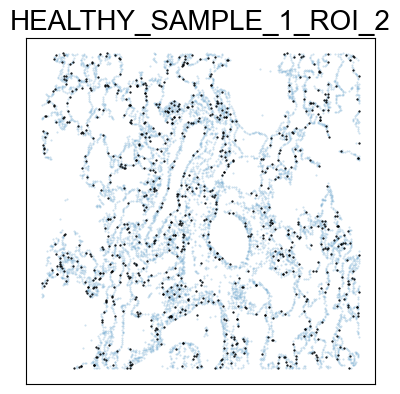

In [30]:
# Choose a broad cell type and a sample to plot

bct = 'all'
example_id = 0
size_factor = 3

fig = plt.figure(figsize=(sizes[roi][0]*size_factor,sizes[roi][1]*size_factor))
roi = rois[example_id]

x = point_clouds[roi, bct][0]
y = point_clouds[roi, bct][1]
x_l = landmarks[roi, bct][0]
y_l = landmarks[roi, bct][1]

plt.scatter(x, y, s=0.2,color='tab:blue',alpha=0.25)
plt.scatter(x_l, y_l, s=0.3,color='black')

plt.title(roi, fontsize=20)
plt.xticks([], []);
plt.yticks([], []);

#### Computations (de-activated)

In [31]:
# # DE-ACTIVATED

# # Choose landmark points. RUN JUST ONCE.

# landmark_ratio = 10 # density parameter

# landmarks = {}

# for s in stages:
#     for roi in sample_ids[s]:
#         for bct in broad_cell_types:
#             x = point_clouds[roi, bct][0]
#             y = point_clouds[roi, bct][1]
#             data = np.vstack((x,y)).T
            
#             num_landmarks = math.ceil(len(data)/landmark_ratio)
#             idx = np.random.randint(len(data), size=num_landmarks)

#             # landmarks[roi,bct] = data[idx,:].T

# # SAVE landmark points as plain text

# for bct in broad_cell_types:
#     with open('landmarks_'+bct+'.txt', 'w') as f:
#         for roi in rois:
#             x_l, y_l = landmarks[roi,bct]
#             f.write(f"# {roi}\n")
#             for x, y in zip(x_l, y_l):
#                 f.write(f"{float(x)} {float(y)}\n")

In [32]:
# # Computation

# witness_dgms_raw = {}

# max_alpha = 100000

# for s in stages:
#     for roi in sample_ids[s]:
#         for bct in broad_cell_types:
#             st = time.time()
    
#             x = point_clouds[roi,bct][0]
#             y = point_clouds[roi,bct][1]
#             data = np.vstack((x,y)).T
    
#             #witness_complex = gudhi.EuclideanWitnessComplex(witnesses=data, landmarks=landmarks[roi,bct].T)
#             #simplex_tree = witness_complex.create_simplex_tree(max_alpha_square=max_alpha, limit_dimension=2)
#             #witness_dgms_raw[group,roi] = simplex_tree.persistence()
    
#             et = time.time()
#             print(roi + ':', round((et - st)/60), 'minutes')

In [33]:
# # Re-run samples that have some infinite persistence point, with larger alpha parameter

# repeats = [['str', 'COVID_SAMPLE_19_ROI_2'], ['imm', 'HEALTHY_SAMPLE_1_ROI_2'],['imm', 'COVID_SAMPLE_19_ROI_2']]

# max_alpha = 200000

# for r in repeats:
    
#     group = r[0]
#     roi = r[1]
    
#     st = time.time()
    
#     x = point_clouds[roi,bct][0]
#     y = point_clouds[roi,bct][1]
#     data = np.vstack((x,y)).T

#     #witness_complex = gudhi.EuclideanWitnessComplex(witnesses=data, landmarks=landmarks[roi,bct].T)
#     #simplex_tree = witness_complex.create_simplex_tree(max_alpha_square=max_alpha, limit_dimension=2)
#     #witness_dgms_raw[group,roi] = simplex_tree.persistence()

#     et = time.time()
#     print(roi + ':', round((et - st)/60), 'minutes')

In [34]:
# # SAVE PYTHON OBJECT
# for bct in broad_cell_types:
#     with open('witness_'+bct+'.txt', "w") as f:
#         for i, (roi_name, dgm) in enumerate(zip(rois, witness_dgms_raw[bct])):
#             f.write(f"# {roi_name}\n")  # Comment line with sample name
#             for dim, (b, d) in dgm:
#                 f.write(f"{i} {dim} {repr(b)} {repr(d)}\n")

## 3. PWDS Visualisation of PH

Example of PWDS for all cells point clouds with alpha filtration.

In [35]:
# Chosen representative samples
examples_ind = [0,5,7,14,16,29]
examples = [rois[i] for i in examples_ind]
degree = 1
filt = 'alpha'
bct = 'all'

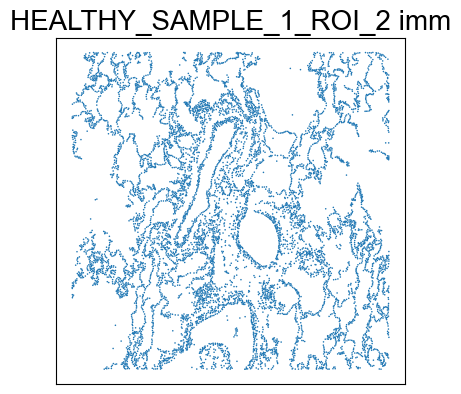

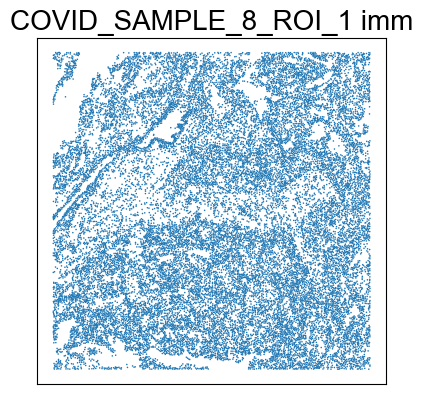

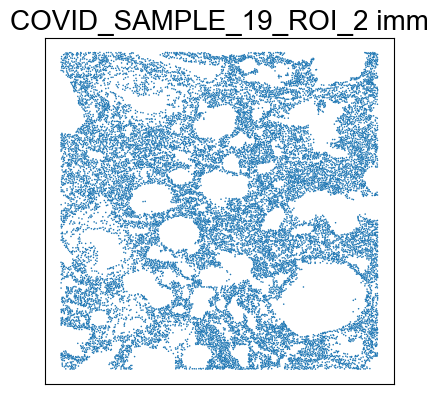

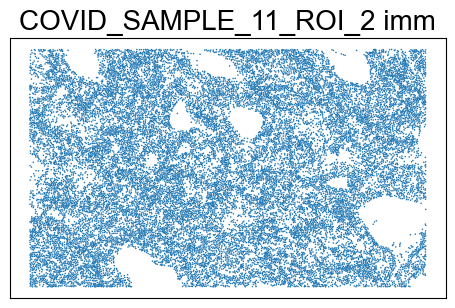

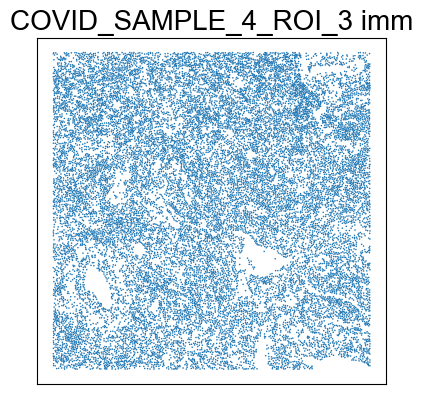

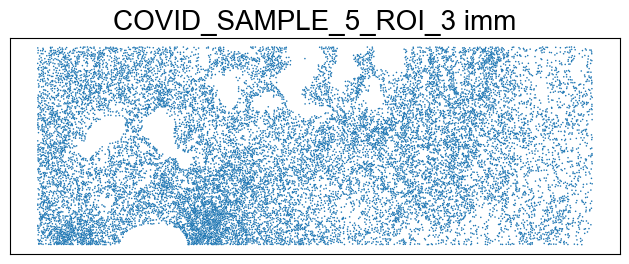

In [36]:
# Plot data examples

size_factor = 3

for i in range(len(examples)):
    roi = examples[i]
    fig = plt.figure(figsize=(sizes[roi][0]*size_factor,sizes[roi][1]*size_factor));
    plt.title(roi + ' ' + ct, fontsize=20)

    x = point_clouds[roi,bct][0]
    y = point_clouds[roi,bct][1]
    plt.scatter(x, y,   s=5, marker = '.', edgecolors ='none', color='tab:blue');
    plt.axis('equal')
    plt.xticks([], [])
    plt.yticks([], [])

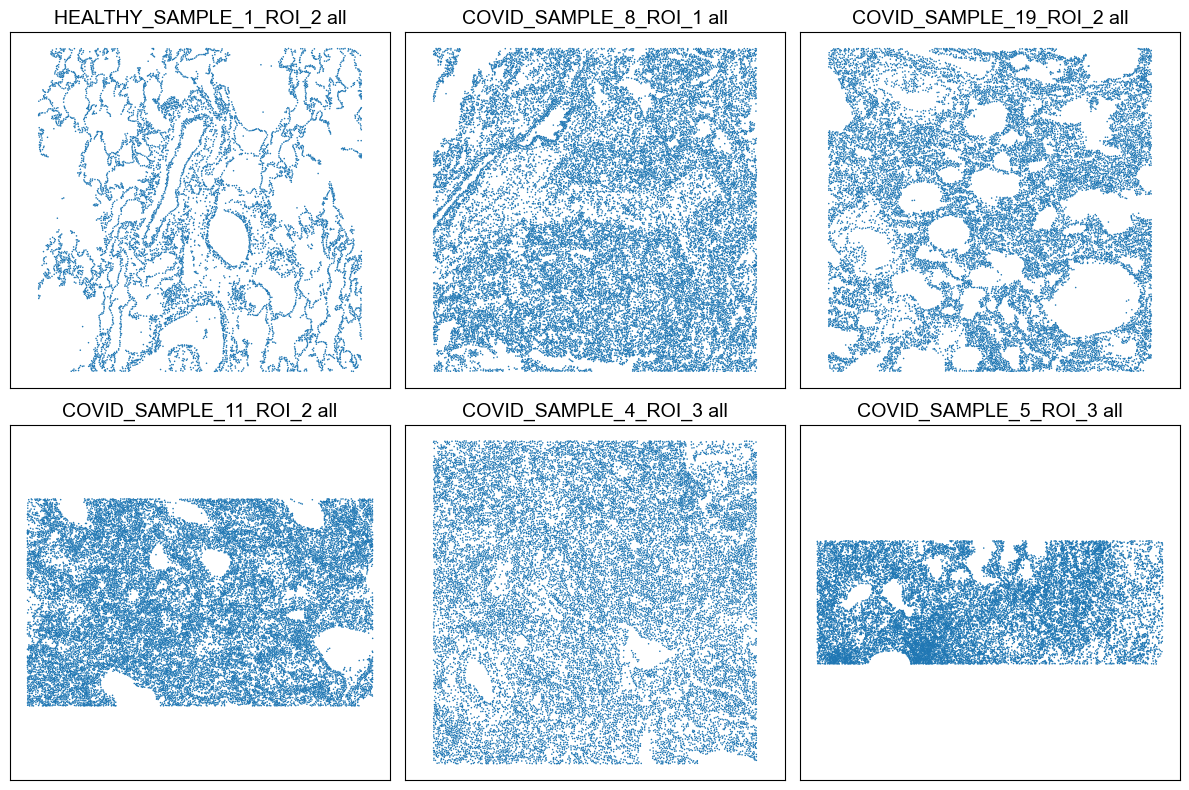

In [37]:
# Grid layout: 2 rows x 3 columns
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))  # Adjust figsize as needed

size_factor = 3

for i, roi in enumerate(examples):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]

    x = point_clouds[roi, bct][0]
    y = point_clouds[roi, bct][1]

    ax.set_title(roi + ' ' + bct, fontsize=14)
    ax.scatter(x, y, s=5, marker='.', edgecolors='none', color='tab:blue')
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused subplots (in case len(examples) < n_rows * n_cols)
for j in range(len(examples), n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

plt.tight_layout()
plt.show()

In [38]:
# We define the birth thresholds as the average of the 90th and 98th percentiles of births in the diagram

birth_threshold = {}

percentiles_list_90 = [np.percentile(d, 90, axis=0)[0] for d in dgms[filt][bct][degree]]
percentiles_list_98 = [np.percentile(d, 98, axis=0)[0] for d in dgms[filt][bct][degree]]
birth_threshold[bct] = [np.mean(percentiles_list_90), np.mean(percentiles_list_98)]

In [39]:
# Choice of colours for the two regions of the diagram

colours_regions = ['firebrick','royalblue']

# Colour gradation between color1 and color2, with t ranging from 0 to 1

def adjust_color(color0, color1, t): # color0 and color1 correspond to color names
    c0 = matplotlib.colors.cnames[color0]
    r0, g0, b0 = matplotlib.colors.to_rgb(c0)
    c1 = matplotlib.colors.cnames[color1]
    r1, g1, b1 = matplotlib.colors.to_rgb(c1)

    return (r1 * t + (1.0 - t) * r0, g1 * t + (1.0 - t) * g0, b1 * t + (1.0 - t) * b0)

# Functions to adjust colour lightness of a colour

def adjust_lightness(color, a): # color needs to be (r, g, b)
    r, g, b = color
    R, G, B = (1,1,1) # White background

    return (r * a + (1.0 - a) * R, g * a + (1.0 - a) * G, b * a + (1.0 - a) * B)

# Lineal lightness adjustment 

def lightness(x, max_pers = 600):
    min_lightness = 0.2
    max_lightness = 1
    return (min_lightness + (x[1]-x[0])*(max_lightness-min_lightness)/max_pers)

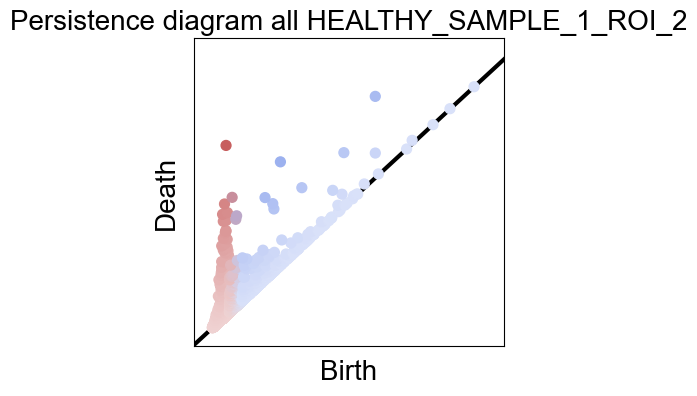

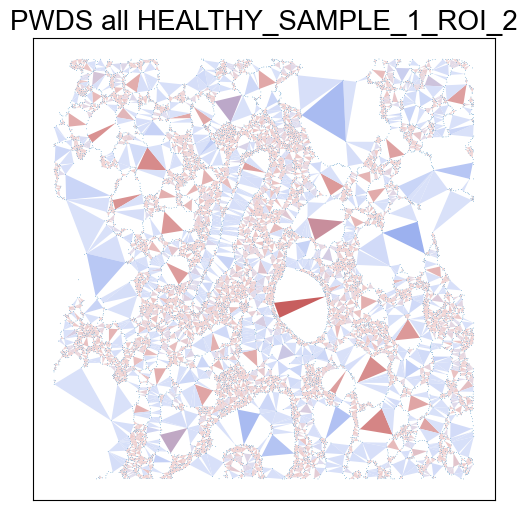

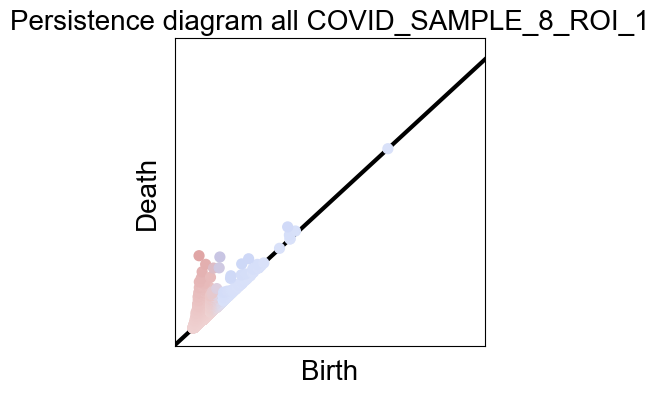

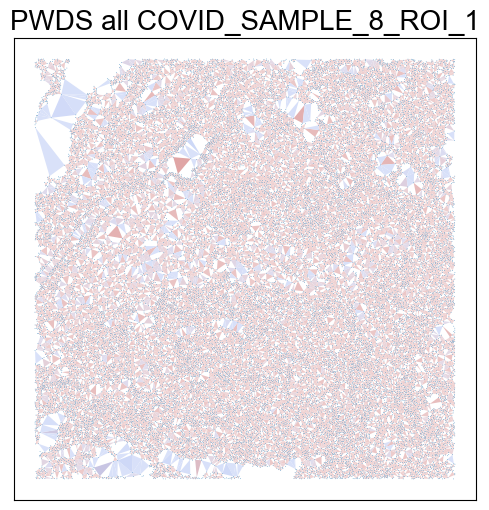

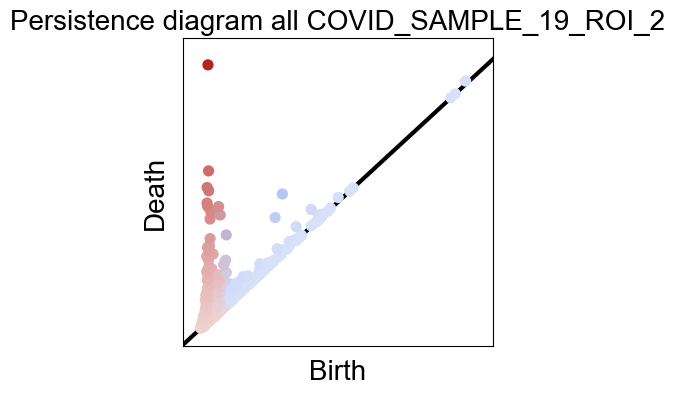

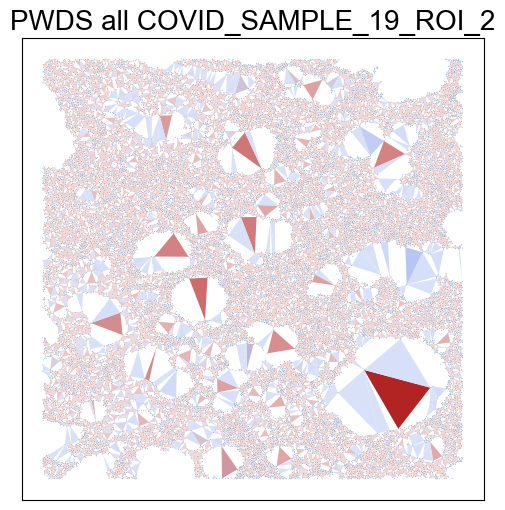

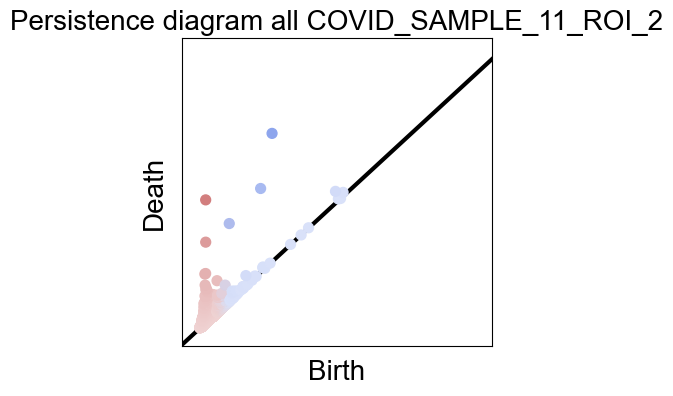

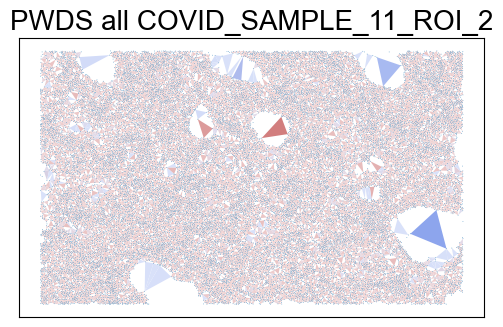

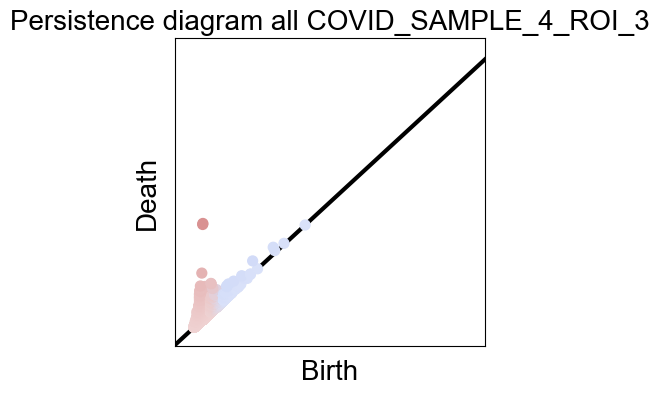

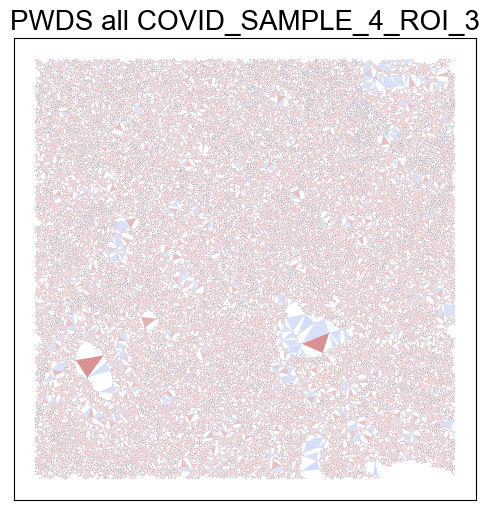

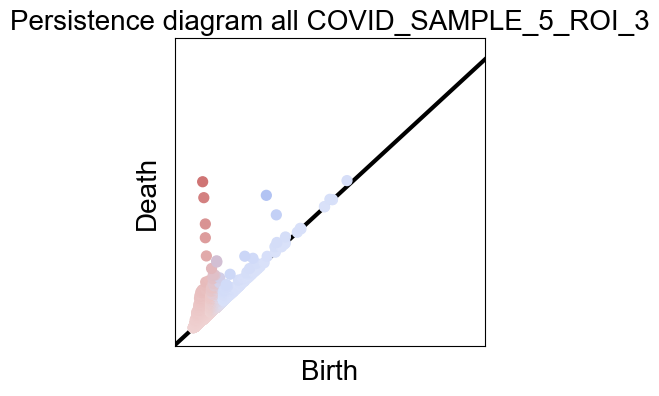

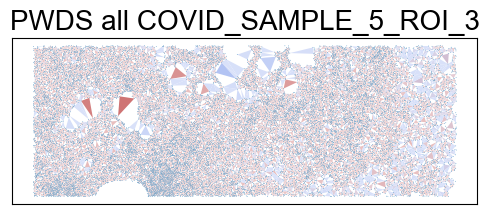

In [40]:
# Continuous change from red to blue

filt = 'alpha'
degree = 1
x_max, y_max = np.vstack([dgms[filt][bct][degree][i] for i in examples_ind]).max(axis=0)

for i in range(len(examples)):
    roi = examples[i]

    data = np.vstack((point_clouds[roi,bct][0], point_clouds[roi,bct][1])).T
    st = gudhi.AlphaComplex(points = data).create_simplex_tree()
    st.compute_persistence()

    simplices_dict = {tuple(sorted(s[0])) : s[1] for s in st.get_simplices()}
    pos = dict(zip(range(len(data)),[(list(x)[0],list(x)[1]) for x in data]))
    pers_pairs_1 = [x for x in st.persistence_pairs() if len(x[1]) == 3]
    point2simplex = {(np.sqrt(simplices_dict[tuple(sorted(x[0]))]), np.sqrt(simplices_dict[tuple(sorted(x[1]))])): x[1] for x in pers_pairs_1}

    num_regions = 3

    divided_dgm = [[] for _ in range(num_regions)]
    shaded_colors = [[] for _ in range(num_regions)]
    max_pers = np.ceil(max([x[1]-x[0] for x in np.vstack(dgms['alpha'][bct][degree])]))

    for x in point2simplex:
        if x[0] < birth_threshold[bct][0]: 
            r, g, b = matplotlib.colors.to_rgb(matplotlib.colors.cnames[colours_regions[0]])
            divided_dgm[0].append(tuple(x)) # proximal cells
            shaded_colors[0].append(adjust_lightness((r,g,b), lightness(x, max_pers=max_pers)))
        if (x[0] >= birth_threshold[bct][0]) and (x[0] <= birth_threshold[bct][1]):
            t = (x[0]- birth_threshold[bct][0])/(birth_threshold[bct][1]-birth_threshold[bct][0])
            divided_dgm[1].append(tuple(x)) # distal cells
            shaded_colors[1].append(adjust_lightness(adjust_color(colours_regions[0], colours_regions[1], t), lightness(x, max_pers=max_pers)))
        if x[0] > birth_threshold[bct][1]:
            r, g, b = matplotlib.colors.to_rgb(matplotlib.colors.cnames[colours_regions[1]])
            divided_dgm[2].append(tuple(x)) # distal cells
            shaded_colors[2].append(adjust_lightness((r,g,b), lightness(x, max_pers=max_pers)))

    # PLOT PERSISTENCE DIAGRAM

    fig = plt.figure(figsize=(4, 4), facecolor='white')

    plt.title('Persistence diagram ' + bct+' '+roi, size = 20)
    plt.xlim(-x_max*0.05,x_max*1.1)
    plt.ylim(-y_max*0.05,y_max*1.1)
    plt.xlabel('Birth', size=20, labelpad = 10.0)
    plt.ylabel('Death', size=20, labelpad = 10.0)
    plt.xticks([], [])
    plt.yticks([], [])
    
    # Diagonal line
    plt.plot([-0.05*max(x_max,y_max),1.1*max(x_max,y_max)], [-0.05*max(x_max,y_max),1.1*max(x_max,y_max)], \
                color='black', linewidth = 3, zorder = 0) 
    
    # Points in persistence diagram
    for r in range(num_regions):
        if len(divided_dgm[r]) > 0:
            plt.scatter(*np.array(divided_dgm[r]).T,s=50, color = shaded_colors[r], zorder=1); 

    # PLOT DEATH SIMPLICES

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xticks([], [])
    ax.set_yticks([], [])
    ax.set_title('PWDS ' + bct+' '+roi, size = 20)

    plt.scatter(*np.array(data).T, s=1, marker = '.', color = 'tab:blue',edgecolors ='none',zorder = 4);

    for r in range(num_regions)[:]:

        triangles = [point2simplex[x]+[lightness(x, max_pers=max_pers)] for x in divided_dgm[r]]
        ax.set_aspect('equal')

        for l in range(len(triangles)):
            i, j, k, s = triangles[l]
            (x0, y0) = pos[i]
            (x1, y1) = pos[j]
            (x2, y2) = pos[k]
            tri = plt.Polygon([ [ x0, y0 ], [ x1, y1 ], [ x2, y2 ] ],
                                edgecolor = None, facecolor = shaded_colors[r][l], 
                                zorder = r, lw=0.5) 
            ax.add_patch(tri);

## 4. Vectorisations

In [41]:
topological_descriptors = {}

### Betti curves

In [42]:
# Computing Betti curves

step = 1

for filt in filtrations:
    for ct in broad_cell_types + cell_types:
        if ct in dgms[filt]: 
            for degree in [0,1]:
                dgms_list = dgms[filt][ct][degree]
                if 0 not in [len(dgm) for dgm in dgms_list]: # Check there are no empty diagrams 
                    v = topological_descriptor(betti_curves(dgms_list, step, normalise = True),ct,filt,degree,'betti')
                    topological_descriptors[v.label] = v

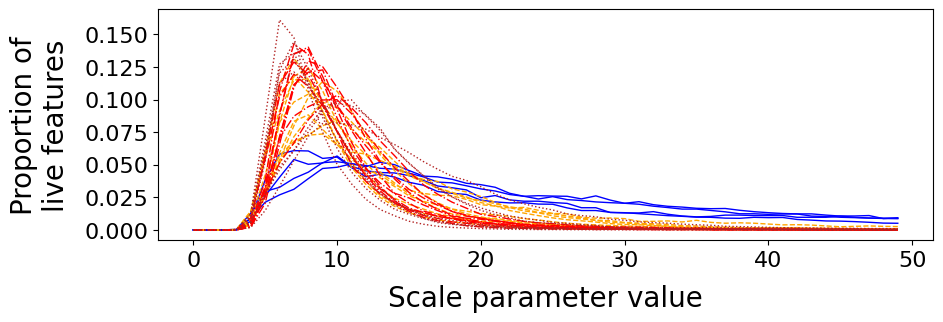

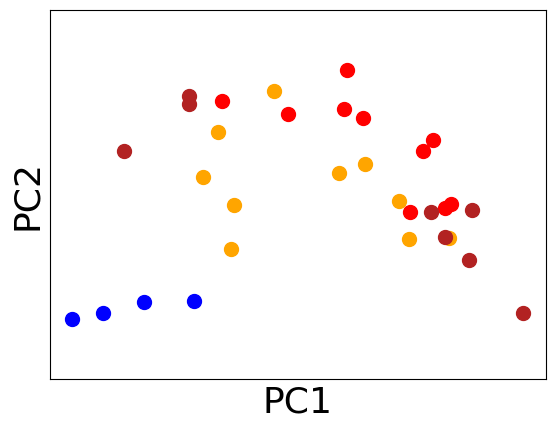

In [43]:
# Choose cell type, degree and max_param
ct = 'all'
degree = 1
max_param = 50

v = topological_descriptors[ct+' alpha H1 betti']
plot_betti_curves(v.vectors,step=1, max_param= max_param, max_y = np.inf, legend = False, save=False);
plot_pca(v.vectors, ticks = False, legend = False, save=False);

### Elementary statistics

In [44]:
births = [10,12,4,14,16] # Percentiles of births (50th == median)
deaths = [11,13,5,15,17] # Percentiles of deaths (50th == median)
lengths = list(range(32,35 + 1)) + [29] # Percentiles of lengths of the bars (and median)

subsets = {'percentiles births': births, 'percentiles deaths': deaths, 'percentiles lengths': lengths}

for filt in filtrations:
    for ct in cell_types + broad_cell_types:
        if ct in dgms[filt]: 
            for degree in [0, 1]: 
                dgms_list = dgms[filt][ct][degree]
                if 0 not in [len(dgm) for dgm in dgms_list]:
                    pers_stats = [GetPersStats(d) for d in dgms_list]
                    if degree == 0:
                        key = 'percentiles lengths'
                        v = topological_descriptor([s[subsets[key]] for s in pers_stats],ct,filt,degree,'stats '+key)
                        topological_descriptors[v.label] = v
                    if degree == 1:
                        for key in subsets:
                            v = topological_descriptor([s[subsets[key]] for s in pers_stats],ct,filt,degree,'stats '+key)
                            topological_descriptors[v.label] = v

### Persistence images

In [45]:
# Weights

def flat_0(b,p, **kwargs):
    lower = nnd_mean / 2
    high = 1.0
    return np.piecewise(p,[p <= lower, p> lower],[lambda p: high*p/lower,lambda p: high])

def flat_1(b,p, **kwargs):
    lower = (1/np.sqrt(3)-1/2)*nnd_mean
    high = 1.0
    return np.piecewise(p,[p <= lower, p> lower],[lambda p: high*p/lower,lambda p: high])

def pers(b,p, **kwargs):
    return p

def pers2(b,p, **kwargs):
    return p**2

def birthpers(b,p, **kwargs):
    return b*p

def birthpers2(b,p, **kwargs):
    return b*p**2

custom_weights_0 = {'flat': flat_0,'p': pers, 'p^2': pers2} # we don't weigh the x-axis for PH0

custom_weights_1 = {'flat': flat_1,'p': pers, 'p^2': pers2, 'bp': birthpers, 'bp^2': birthpers2}

custom_weights = [custom_weights_0, custom_weights_1]

In [46]:
# Deciding resolutions based on small scale and maximum persistence values

size_pxl = {}

for point_cloud in broad_cell_types:
    size_pxl[point_cloud,'alpha', 0] = 5
    size_pxl[point_cloud,'alpha', 1] = 10
    size_pxl[point_cloud,'witness', 1] = 25

for point_cloud in cell_types:
    size_pxl[point_cloud,'alpha', 0] = 5
    size_pxl[point_cloud,'alpha', 1] = 10

size_sigma = size_pxl # We set the variance of the Gaussians to be the same as the size of the pixels. 

In [47]:
# Computation of persistence images

for ct in broad_cell_types + cell_types:
    for filt in filtrations:
        for degree in [0,1]:
            if (ct,filt,degree) in size_pxl: # We don't have all the possible combinations

                dgms_list = dgms[filt][ct][degree]

                if 0 not in [len(dgm) for dgm in dgms_list]: # If some diagrams are empty, we don't compute the vectorisations

                    if degree==0:
                        # TRICK: in order to get persistence images from a PD where all points have the same birth value,
                        # we add an artificial point at (1,0) for each diagram. Since the weighting function needs to be 0 
                        # at y-x = 0, this point will not contribute to the persistence surface.

                        for i in range(len(dgms_list)):
                            dgms_list[i] = np.concatenate((dgms_list[i], np.array([[1,1]])), axis=0)

                    pxl = size_pxl[ct,filt,degree]
                    sigma = size_sigma[ct,filt,degree]

                    for weight_label in custom_weights[degree]: 
                        pimgr = PersistenceImager(pixel_size=pxl)
                        pimgr.fit(dgms_list)

                        # Choose a linear weight function to give more importance to higher persistence features
                        pimgr.weight = custom_weights[degree][weight_label]

                        # Choose a higher variance of the gaussian functions centered at each point
                        pimgr.kernel_params = {'sigma': sigma}

                        # Compute and create top descriptor object
                        pi = topological_descriptor(vectors=pimgr.transform(dgms_list, skew=True), point_cloud=ct,\
                                                    filtration=filt, degree=degree, type='persim w='+weight_label)

                        pi.pi_shape = np.shape(pi.vectors[0]) # All images have the same shape. This allows us to recover the image later to plot it

                        # Save flattened vectors and add topological_descriptor to list
                        pi.vectors = np.array([image.flatten() for image in pi.vectors])

                        topological_descriptors[pi.label] = pi

## 5. Clustering

### Computation

In [48]:
# Computation of clustering

for key in topological_descriptors:
    v = topological_descriptors[key]

    # 2-clustering
    km = KMeans(n_clusters = 2, n_init=100).fit(v.vectors) # n_init=100
    v.twoclust = km.labels_.tolist()
    
    # 4-clustering
    km = KMeans(n_clusters = 4, n_init=100).fit(v.vectors) # n_init=100
    v.fourclust = km.labels_.tolist()
    
    # 3-clustering
    km = KMeans(n_clusters = 3,n_init=100).fit(v.vectors[stages_len[0]:])
    v.threeclust = km.labels_.tolist()

### Evaluation and table of results

In [49]:
true_labels_2 = stages_len[0]*[0]+sum(stages_len[1:])*[1]

true_labels_4 = []
for i in range(len(stages_len)):
    true_labels_4+=stages_len[i]*[i]

true_labels_3 = true_labels_4[stages_len[0]:]

In [50]:
headers = ['Point cloud', 'Filtration', 'Degree','Vectorisation', '2-clustering', '4-clustering', '4-clust separates healthy', '3-clustering']

# Create a results data frame
results_df = pd.DataFrame(columns=headers)

for ct in broad_cell_types + cell_types:
    keys_ct = [k for k in topological_descriptors if topological_descriptors[k].point_cloud == ct]
    for filt in filtrations:
        keys_filtr = [k for k in keys_ct if topological_descriptors[k].filtration == filt]
        for degree in [0,1]:
            keys_degree = [k for k in keys_filtr if topological_descriptors[k].degree == degree]
            for key in keys_degree:
                v = topological_descriptors[key]
                res = [v.point_cloud, v.filtration, '$H_'+str(v.degree)+'$']

                if v.type[:6]=='persim':
                    res.append('persim '+ '$' + v.type[7:]+ '$')
                else:
                    res.append(v.type)
                
                # 2-clustering evaluation with silhouette score
                if good_clustering(v.twoclust,true_labels_2):
                    silhouette = round(sil_score(v.vectors, v.twoclust),4)
                    res.append(str(silhouette))
                else:
                    res.append(str('--'))

                # 4-clustering evaluation with silhouette score
                if good_clustering(v.fourclust,true_labels_4):
                    silhouette = round(sil_score(v.vectors, v.fourclust),4)
                    res.append(str(silhouette))
                else:
                    res.append(str('--'))

                # 4-clustering separates helthy
                if partial_clustering(v.fourclust,true_labels_4, [0]):
                    res.append('Y')
                else:
                    res.append('N')

                # 3-clustering evaluation with silhouette score
                if good_clustering(v.threeclust,true_labels_3):
                    silhouette = round(sil_score(v.vectors[stages_len[0]:], v.threeclust),3)
                    res.append(str(silhouette))
                else:
                    res.append(str('--'))

                results_df.loc[len(results_df)] = res

results_df.head(5)

,Point cloud,Filtration,Degree,Vectorisation,2-clustering,4-clustering,4-clust separates healthy,3-clustering
0,all,alpha,$H_0$,betti,--,--,N,--
1,all,alpha,$H_0$,stats percentiles lengths,--,--,N,--
2,all,alpha,$H_0$,persim $w=flat$,--,--,N,--
3,all,alpha,$H_0$,persim $w=p$,--,--,N,--
4,all,alpha,$H_0$,persim $w=p^2$,--,--,N,--


In [51]:
# Only positive results, sorted by quality of the clustering

positive_results_sorted = results_df[(results_df['2-clustering']!= '--') | (results_df['4-clustering']!= '--') | (results_df['4-clust separates healthy']== 'Y')].sort_values(['2-clustering'], ascending=[False])

pd.set_option("display.max_rows",None) 
positive_results_sorted

,Point cloud,Filtration,Degree,Vectorisation,2-clustering,4-clustering,4-clust separates healthy,3-clustering
17,all,witness,$H_1$,stats percentiles lengths,0.8327,--,Y,--
53,imm,alpha,$H_1$,stats percentiles deaths,0.7958,--,N,--
52,imm,alpha,$H_1$,stats percentiles births,0.7884,--,N,--
63,imm,witness,$H_1$,stats percentiles lengths,0.7666,--,N,--
54,imm,alpha,$H_1$,stats percentiles lengths,0.7389,--,N,--
47,imm,alpha,$H_0$,stats percentiles lengths,0.736,--,N,--
60,imm,witness,$H_1$,betti,0.7025,--,N,--
51,imm,alpha,$H_1$,betti,0.6429,--,Y,--
46,imm,alpha,$H_0$,betti,0.6394,--,N,--
13,all,alpha,$H_1$,persim $w=bp^2$,0.4929,--,N,--


### 3-clustering Rand score analysis

In [52]:
correctness_scores = []

for key in topological_descriptors:
    v = topological_descriptors[key]

    unlabeled_scores = [rand_score_pers(true_labels_3,v.threeclust)]

    for k in range(1,len(stages_len)):
        start_point = sum(stages_len[1:k])
        end_point = sum(stages_len[1:k+1])
        unlabeled_scores.append(rand_score_pers(true_labels_3,v.threeclust, subset = range(start_point, end_point)))

    correctness_scores.append([key,unlabeled_scores])

In [53]:
# Find best clusterings
# j = 0: overall rand score
# j = 1: Alveolitis rand score
# j = 2: DAD rand score
# j = 3: OP rand score

j = 0

best_rand = sorted(correctness_scores,key=lambda x: -x[1][j])

for i in range(10):
    key_ = best_rand[i]
    v = topological_descriptors[key_[0]]
    labels = relabel(v.threeclust)
    sil_sc = round(sil_score(v.vectors[stages_len[0]:], labels),4)
    labels.insert(stages_len[1], '|')
    labels.insert(sum(stages_len[1:3])+1,'|')
    print(labels, key_[0], 'score= ', round(key_[1][j],4), 'sil_score: ', sil_sc)
    plt.close()

[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, '|', 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, '|', 2, 2, 2, 2, 2, 1, 1, 1] Endothelial cells alpha H1 stats percentiles deaths score=  0.746 sil_score:  0.5331
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, '|', 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, '|', 2, 2, 2, 2, 2, 1, 1, 1] Endothelial cells alpha H1 stats percentiles lengths score=  0.7328 sil_score:  0.5612
[0, 0, 0, 0, 0, 1, 0, 1, 0, 1, '|', 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, '|', 2, 2, 2, 2, 2, 1, 1, 1] Endothelial cells alpha H1 stats percentiles births score=  0.7222 sil_score:  0.5314
[0, 0, 0, 1, 0, 2, 0, 0, 0, 2, '|', 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, '|', 1, 1, 1, 1, 1, 2, 2, 2] Prolif endothelial cells alpha H0 betti score=  0.6852 sil_score:  0.5762
[0, 0, 0, 1, 0, 2, 0, 0, 0, 2, '|', 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, '|', 1, 1, 1, 1, 1, 2, 2, 2] Prolif endothelial cells alpha H0 stats percentiles lengths score=  0.6852 sil_score:  0.6249
[0, 0, 0, 0, 0, 1, 0, 1, 0, 1, '|', 2, 2, 2, 0, 0, 2, 0, 2, 2, 2, '|', 2, 2, 2, 2, 2, 1, 1, 1] Endo

In [54]:
key = best_rand[0][0]
v = topological_descriptors[key]
print(label2cluster(relabel(v.threeclust), rois_titles[stages_len[0]:]))

{0: ['ALV8R3', 'ALV8R1', 'ALV20R2', 'ALV19R2', 'ALV14R2', 'ALV20R17', 'ALV6R3', 'ALV6R1'], 1: ['ALV14R1', 'ALV6R2', 'DAD4R2', 'OP5R3', 'OP5R1', 'OP5R2'], 2: ['DAD11R2', 'DAD11R1', 'DAD4R3', 'DAD9R2', 'DAD9R1', 'DAD17R1', 'DAD17R2', 'DAD17R3', 'DAD17R4', 'OP16R3', 'OP19R1', 'OP16R1', 'OP10R2', 'OP10R3']}


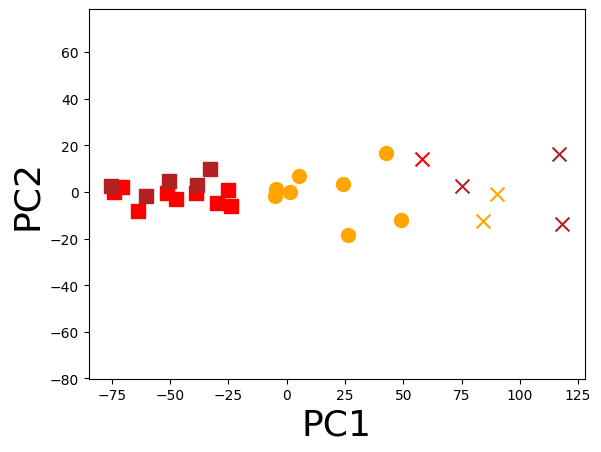

In [55]:
# PCA of best descriptor
# Colour indicates stage of disease
# Shape of marker indicates clusters identified by the topological descriptor

plot_pca_diseased(v.vectors, save = False, clustering = v.threeclust);

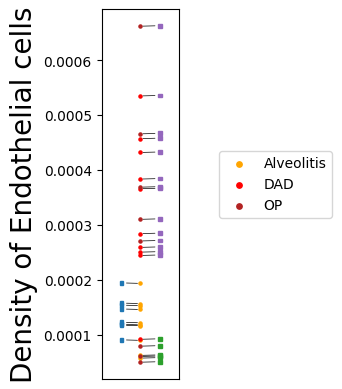

In [56]:
# Relation to density

colors_clusters = ['tab:blue','tab:green', 'tab:purple']
labels_clusters = ['Aprox ALV cluster', 'Sparse samples cluster','Aprox DAD and OP cluster']

data = topological_descriptors[best_rand[0][0]].point_cloud

densities_clusters = label2cluster(true_labels_3, densities[data][stages_len[0]:])

fig, ax = plt.subplots()

fig.set_figwidth(1)

plt.xticks([])
plt.xlim(-0.5,0.5)
plt.ylabel('Density of Endothelial cells', size=20)

count = stages_len[0]
for i in range(1,len(stages)):
    features = densities[data][count: count + stages_len[i]]
    ax.scatter([0]*len(features), features, color = stages_colors[i], s = 5, label = stages[i])
    count += stages_len[i]

# Add annotations according to best clustering

descriptor = topological_descriptors[best_rand[0][0]]
densities_clusters = label2cluster(relabel(descriptor.threeclust), densities[descriptor.point_cloud][stages_len[0]:])

for label in densities_clusters:
    features = densities_clusters[label]
    side_of_point=1
    if label==0:
        side_of_point=-1
    
    for point in features:
        ax.annotate('a',[0,point],xytext=[side_of_point*0.25,point], size = 0.2,color=colors_clusters[label],
                    arrowprops=dict(arrowstyle='-',
                                    linewidth=0.5),
                    bbox=dict(facecolor=colors_clusters[label],
                              edgecolor=colors_clusters[label],
                              pad=1))
    
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))       
lgnd = fig.legend(by_label.values(), by_label.keys() ,bbox_to_anchor=(2.5,0.6))

for i in range(0,len(densities_clusters)):
    lgnd.legend_handles[i]._sizes = [15]


In [57]:
# A direct clustering of the densities doesn't yield the same clusters

descriptor = topological_descriptors[best_rand[0][0]]
km = KMeans(n_clusters = 3).fit(np.array(densities[descriptor.point_cloud][stages_len[0]:]).reshape(-1, 1))
km.labels_

labels = relabel(km.labels_)
labels.insert(stages_len[1], '|')
labels.insert(sum(stages_len[1:3])+1,'|')
print(labels)

[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, '|', 1, 2, 1, 1, 0, 2, 1, 2, 2, 2, '|', 2, 2, 1, 1, 2, 0, 0, 0]


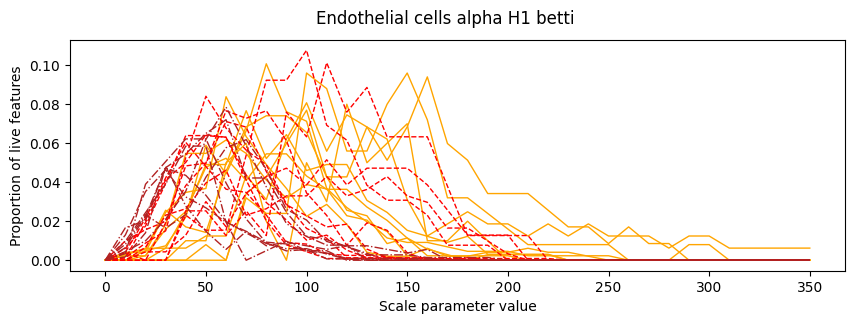

In [58]:
# What are the topological differences (beyond density) in Endothelial cells?
# Looking at the Betti curves of degree 1 may help.

filtration = 'alpha'
step = 10
data = 'Endothelial cells'
degree = 1
dgms = alpha_dgms[data][degree]
v = topological_descriptor(betti_curves(dgms, step),data,filtration,degree,'betti')

plot_betti_curves_diseased(v.vectors,title= v.label,step=step, save = False);

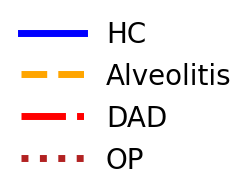

In [59]:
legend_elements = [Line2D([0,1], [0,0], color=stages_colors[i], linewidth = 5, linestyle = line_styles[i],\
                          label=stages[i]) for i in range(len(stages))]

# Create the figure
fig, ax = plt.subplots(1,1, figsize=(2, 2))
ax.legend(handles=legend_elements, handlelength=2.25, loc='center',prop={'size':20},frameon=False)
ax.axis('off');